In [80]:
### Imports ###
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,FunctionTransformer,OrdinalEncoder
from sklearn.pipeline import Pipeline
import os,time,py7zr,datetime,random

In [3]:
### Set Seed ###
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.15.1


In [87]:
### Extract Data ###

#Note: This extraction process is necessary because the raw CSV files are too large to upload to GitHub normally, and Kaggle's importer is broken. 
#The Zip is used to get under the maximum file size for a free account with Git LFS
MAX_ROWS=1000000
if not os.path.isdir('readableData'):
    print("No CSV Directory Found, Creating & Extracting...")
    ##Create folder to hold CSV files
    os.makedirs("readableData", exist_ok=True)
    ##Extract Zip
    unzipper = ZipFile("favorita-grocery-sales-forecasting.zip", 'r')
    unzipper.extractall(path="readableData")
    ##Extract 7z Files
    for fileName in os.listdir("readableData"):
        if fileName.split(".")[-1] == "7z":
            sevenZFile = py7zr.SevenZipFile("readableData/"+fileName, 'r')
            sevenZFile.extractall(path="readableData")
            os.remove("readableData/"+fileName)
print("Data present as CSVs, reading...")
ds  = pd.read_csv(f'readableData/train.csv',index_col='id',dtype={"onpromotion":bool},parse_dates=['date'],nrows=MAX_ROWS,date_parser = pd.to_datetime,
                        converters={
                            "onpromotion" : lambda x : float(bool(x))
                        })
ds.head()

Data present as CSVs, reading...


/tmp/ipykernel_2206807/782640755.py:20: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds  = pd.read_csv(f'readableData/train.csv',index_col='id',dtype={"onpromotion":bool},parse_dates=['date'],nrows=MAX_ROWS,date_parser = pd.to_datetime,
/tmp/ipykernel_2206807/782640755.py:20: ParserWarning: Both a converter and dtype were specified for column onpromotion - only the converter will be used.
  ds  = pd.read_csv(f'readableData/train.csv',index_col='id',dtype={"onpromotion":bool},parse_dates=['date'],nrows=MAX_ROWS,date_parser = pd.to_datetime,


,date,store_nbr,item_nbr,unit_sales,onpromotion
id,,,,,
0,2013-01-01,25,103665,7.0,0.0
1,2013-01-01,25,105574,1.0,0.0
2,2013-01-01,25,105575,2.0,0.0
3,2013-01-01,25,108079,1.0,0.0
4,2013-01-01,25,108701,1.0,0.0


In [100]:
### Data Preprocessing ###

X = ds[["date","store_nbr","item_nbr","unit_sales","onpromotion"]]
y = ds["unit_sales"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4 ,
    random_state=SEED ,

)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
)
"""
dat_cols = X_train.select_dtypes(
    include=['datetime']
).columns.tolist()

cat_cols = X_train.select_dtypes(
    include=['object','category']
).columns.tolist() + X_train["item_nbr"]

num_cols = X_train.select_dtypes(
    exclude=['object','category','datetime']
).columns.tolist() - X_train["item_nbr"]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)
print("DateTime columns: ",dat_cols)"""
dat_cols = X_train[["date"]]
cat_cols = X_train[["store_nbr","item_nbr","onpromotion"]]
##Build preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), cat_cols),
        ("datetime",OrdinalEncoder(),dat_cols),
    ],
    remainder="drop"
)

X_train_p = preprocess.fit_transform(X_train)
X_val_p   = preprocess.transform(X_val)
X_test_p  = preprocess.transform(X_test)
# Verify processed feature shapes
print("Processed shapes:", X_train_p.shape, X_val_p.shape, X_test_p.shape)


ValueError: No valid specification of the columns. Only a scalar, list or slice of all integers or all strings, or boolean mask is allowed

In [92]:
### Build First Model ###
def build_basic_model(
    input_dim: int,
    depth: int = 5,                     
    width: int = 100,                     
    activation: str = "relu",                
    kernel_initializer: str | keras.initializers.Initializer = None,
    use_batchnorm: bool = False,             
    dropout_rate: float = 0,             
    l2_weight: float = 0,            
) -> keras.Model:

    reg = keras.regularizers.L2(l2=l2_weight) if l2_weight and l2_weight > 0 else None

    inputs = keras.Input(shape=(input_dim ,))
    x = inputs

    for _ in range(depth):
        x = layers.Dense(
            width, 
            activation=None,
            kernel_initializer=kernel_initializer,
            kernel_regularizer=reg ,
        )(x)

        if use_batchnorm:
            x = layers.BatchNormalization()(x)

        x = layers.Activation(activation=activation)(x)

        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(rate=dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

input_dim = X_train_p.shape[1]
deep_model = build_basic_model(input_dim=input_dim, depth=6, width=256)
deep_model.summary()

Model: "model_29"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_30 (InputLayer)       [(None, 5)]               0         
                                                                 
 dense_223 (Dense)           (None, 256)               1536      
                                                                 
 activation_194 (Activation  (None, 256)               0         
 )                                                               
                                                                 
 dense_224 (Dense)           (None, 256)               65792     
                                                                 
 activation_195 (Activation  (None, 256)               0         
 )                                                               
                                                                 
 dense_225 (Dense)           (None, 256)               657

In [93]:
### Compile & Fit Functions ###

def compile_model(model: keras.Model, optimizer: keras.optimizers.Optimizer):
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.MeanSquaredError(),
        metrics=["accuracy"]
    )
    return model

def fit_model(model: keras.Model, epochs: int = 20, batch_size: int = 256):
    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=True
    )
    return history

print(X_train_p)
print(y_train)
print(X_val_p)
print(y_val)

[[-1.05289764  0.74467843 -0.18224282  0.          9.        ]
 [ 1.01181373  0.74427315 -0.18224282  0.         13.        ]
 [ 0.46527248 -1.32696496  0.36880182  0.          6.        ]
 ...
 [-1.05289764  0.61039457  0.21851692  0.          4.        ]
 [ 0.7081797   0.56780028  0.56918169  0.         17.        ]
 [ 1.67980858 -0.99642185 -0.3826227   0.          3.        ]]
id
333136     5.0
515905     5.0
230477    16.0
967322    14.0
610942     5.0
          ... 
259178    47.0
365838    27.0
131932    13.0
671155    20.0
121958     1.0
Name: unit_sales, Length: 600000, dtype: float64
[[-0.87071722  0.48745205 -0.28243276  0.         14.        ]
 [ 1.07254053  1.12336788  0.21851692  0.         12.        ]
 [-1.47798527  0.85366998  0.46899176  0.          6.        ]
 ...
 [ 1.01181373  1.05949458 -0.3826227   0.         10.        ]
 [ 0.6474529  -1.48896625 -0.18224282  0.         17.        ]
 [ 1.67980858 -1.52255534 -0.3826227   0.         17.        ]]
id
536753     3

Epoch 1/20
2344/2344 [==============================] - 4s 2ms/step - loss: 456.9262 - accuracy: 0.1735 - val_loss: 410.1925 - val_accuracy: 0.1739
Epoch 2/20
2344/2344 [==============================] - 3s 1ms/step - loss: 456.8291 - accuracy: 0.1735 - val_loss: 410.1884 - val_accuracy: 0.1739
Epoch 3/20
2344/2344 [==============================] - 3s 1ms/step - loss: 456.8260 - accuracy: 0.1735 - val_loss: 410.1870 - val_accuracy: 0.1739
Epoch 4/20
2344/2344 [==============================] - 3s 1ms/step - loss: 456.8256 - accuracy: 0.1735 - val_loss: 410.1863 - val_accuracy: 0.1739
Epoch 5/20
2344/2344 [==============================] - 4s 1ms/step - loss: 456.8248 - accuracy: 0.1735 - val_loss: 410.1859 - val_accuracy: 0.1739
Epoch 6/20
2344/2344 [==============================] - 4s 1ms/step - loss: 456.8250 - accuracy: 0.1735 - val_loss: 410.1857 - val_accuracy: 0.1739
Epoch 7/20
2344/2344 [==============================] - 4s 1ms/step - loss: 456.8241 - accuracy: 0.1735 - val_lo

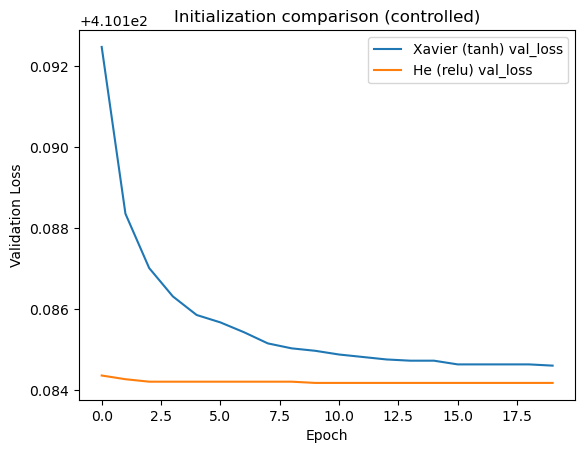

In [95]:
### Compile & Fit Different Model Types ###
xavier = keras.initializers.GlorotNormal(seed=SEED)
he     = keras.initializers.HeNormal(seed=SEED)

model_xavier = compile_model(
    build_basic_model(
        input_dim=input_dim,
        depth=10,
        width=10,
        activation="tanh",
        kernel_initializer=xavier
    ),
    keras.optimizers.SGD(learning_rate=1e-2)
)

model_he = compile_model(
    build_basic_model(
        input_dim=input_dim,
        depth=10,
        width=10,
        activation="relu",
        kernel_initializer=he
    ),
    keras.optimizers.SGD(learning_rate=1e-2)
)

# function call- do not change
hist_xavier = fit_model(model_xavier, epochs=20)
hist_he = fit_model(model_he, epochs=20)

plt.figure()
plt.plot(hist_xavier.history["val_loss"], label="Xavier (tanh) val_loss")
plt.plot(hist_he.history["val_loss"], label="He (relu) val_loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Initialization comparison (controlled)")
plt.show()